# DEG 분석
C1QC+ TAM과 SPP1+ TAM, 그리고 나머지 Unknown TAM 사이에서 어떤 유전자가 차등 발현되는지 찾는 것.

먼저 이전 단계에서 annoation 해두었던 mac의 raw count 데이터를 불러온다

Raw AnnData with n_obs × n_vars = 9106 × 41861
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'


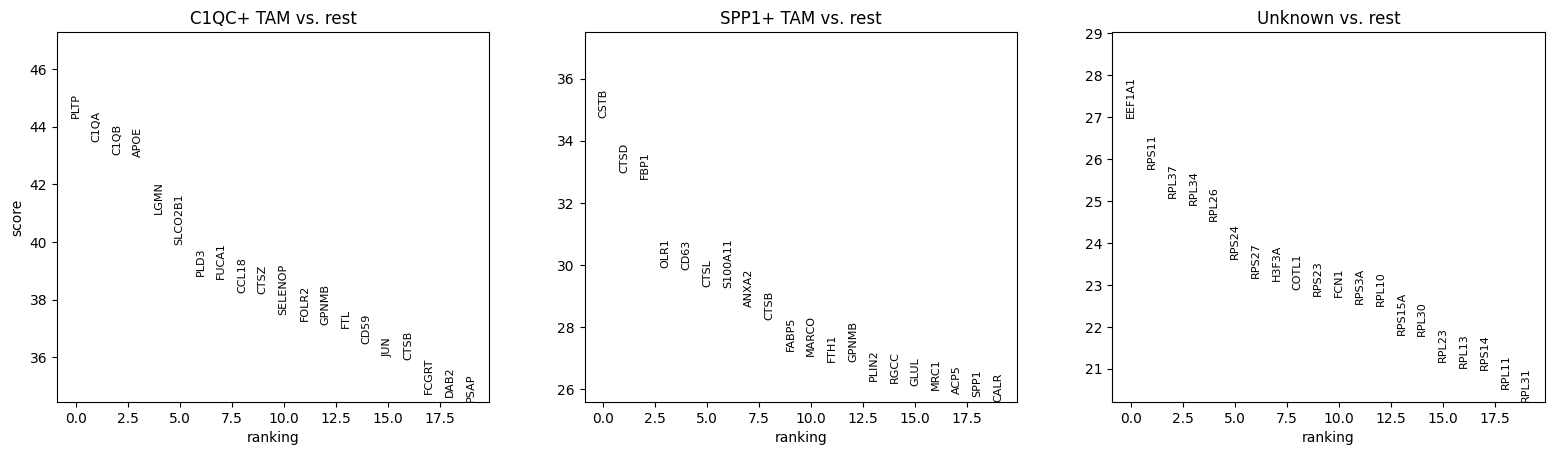

In [1]:
import scanpy as sc

mac = sc.read_h5ad('../phase1_scrna/dataset/GSE127465_mac_subtyped.h5ad')

# 1. raw 값으로 DEG 돌려야하니 확인
print(mac.raw)

# 2. DEG 실행
sc.tl.rank_genes_groups(
    mac,
    groupby='tam_subtype',
    method='wilcoxon',
    key_added='deg_tam',
    use_raw=True
)

# 3. 결과 확인
sc.pl.rank_genes_groups(mac, n_genes=20, key='deg_tam', sharey=False)

In [ ]:
import pandas as pd

# 논문 기준 marker gene
paper_markers = {
    'C1QC+ TAM': ['C1QA', 'C1QB', 'C1QC', 'APOE', 'FOLR2'],
    'SPP1+ TAM': ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63'],
}

# 내 DEG top 50 추출
for group in ['C1QC+ TAM', 'SPP1+ TAM']:
    my_genes = sc.get.rank_genes_groups_df(
        mac, group=group, key='deg_tam'
    )['names'].head(50).tolist()
    
    # 내 top 50이랑 논문 marker 5개 둘 다 포함 된 유전자만 추출 - 순서 없이 겹치는 것만
    overlap = set(my_genes) & set(paper_markers[group])
    
    print(f"\n{group}")
    print(f"  논문 markers: {paper_markers[group]}")
    print(f"  내 top 50 overlap: {overlap}")


C1QC+ TAM
  논문 markers: ['C1QA', 'C1QB', 'C1QC', 'APOE', 'FOLR2']
  내 top 50 overlap: {'C1QA', 'APOE', 'C1QC', 'C1QB', 'FOLR2'}

SPP1+ TAM
  논문 markers: ['SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63']
  내 top 50 overlap: {'MRC1', 'GPNMB', 'CTSD', 'SPP1', 'CD63'}


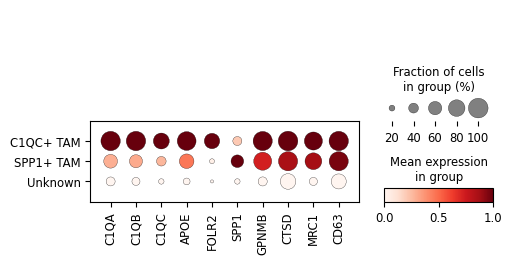

In [3]:
mac.write('../phase1_scrna/dataset/GSE127465_mac_phase2a.h5ad')

# 추가 시각화
sc.pl.dotplot(mac, 
    var_names=['C1QA', 'C1QB', 'C1QC', 'APOE', 'FOLR2',
               'SPP1', 'GPNMB', 'CTSD', 'MRC1', 'CD63'],
    groupby='tam_subtype',
    standard_scale='var'
)